# 14b visualize patchy template family

文献系の軽量 patchy $C_L^{\tau\tau}$ family を使った anisotropic CB 再解釈を見る notebook です。

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('/home/yminami/workdir/CosmicBirefringence/PatchyReionization')
RESULT = ROOT / 'results/14-patchy-template-family'
shapes = pd.read_csv(RESULT / 'template_family_shapes.csv')
summary = pd.read_csv(RESULT / 'template_family_bound_summary.csv')
summary.head()


,template_name,mass_eV,A_unit,phi_amp_max,A_tau_eff,L_peak_template,sigma_log,L_at_window_peak,max_shape_in_window,D_peak_limit,C_limit_at_window_peak
0,Lpeak_20_siglog_0.3,2.030918e-27,1.105005e+10,18124.866293,2.002807e+14,20.0,0.3,20,1.0,2.492998e-33,3.729517e-35
1,Lpeak_20_siglog_0.5,2.030918e-27,1.105005e+10,18124.866293,2.002807e+14,20.0,0.5,20,1.0,2.492998e-33,3.729517e-35
2,Lpeak_20_siglog_0.8,2.030918e-27,1.105005e+10,18124.866293,2.002807e+14,20.0,0.8,20,1.0,2.492998e-33,3.729517e-35
3,Lpeak_50_siglog_0.3,2.030918e-27,1.105005e+10,18124.866293,2.002807e+14,50.0,0.3,50,1.0,2.492998e-33,6.142734e-36
4,Lpeak_50_siglog_0.5,2.030918e-27,1.105005e+10,18124.866293,2.002807e+14,50.0,0.5,50,1.0,2.492998e-33,6.142734e-36


## Template family shapes

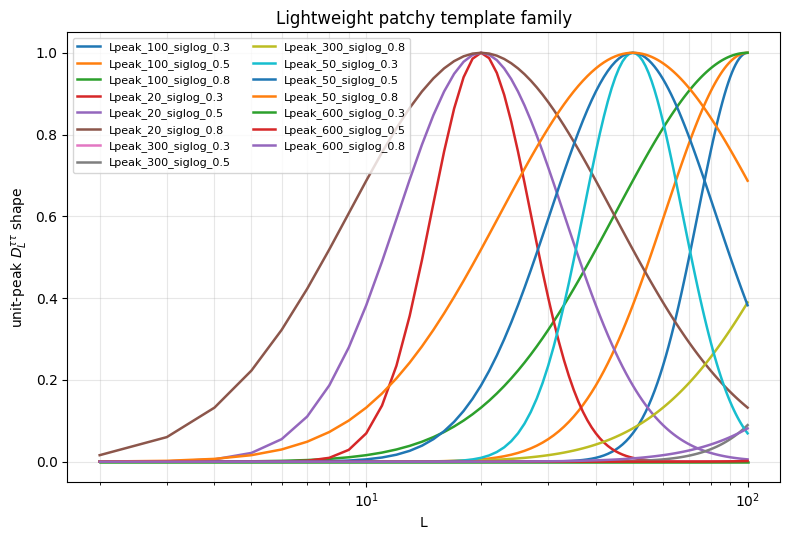

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for name, grp in shapes.groupby('template_name'):
    ax.semilogx(grp['L'], grp['D_shape_unit_peak'], lw=1.8, label=name)
ax.set_xlabel('L')
ax.set_ylabel(r'unit-peak $D_L^{\tau\tau}$ shape')
ax.set_title('Lightweight patchy template family')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## Allowed peak $D_L^{\tau\tau}$ vs template $L_{\rm peak}$

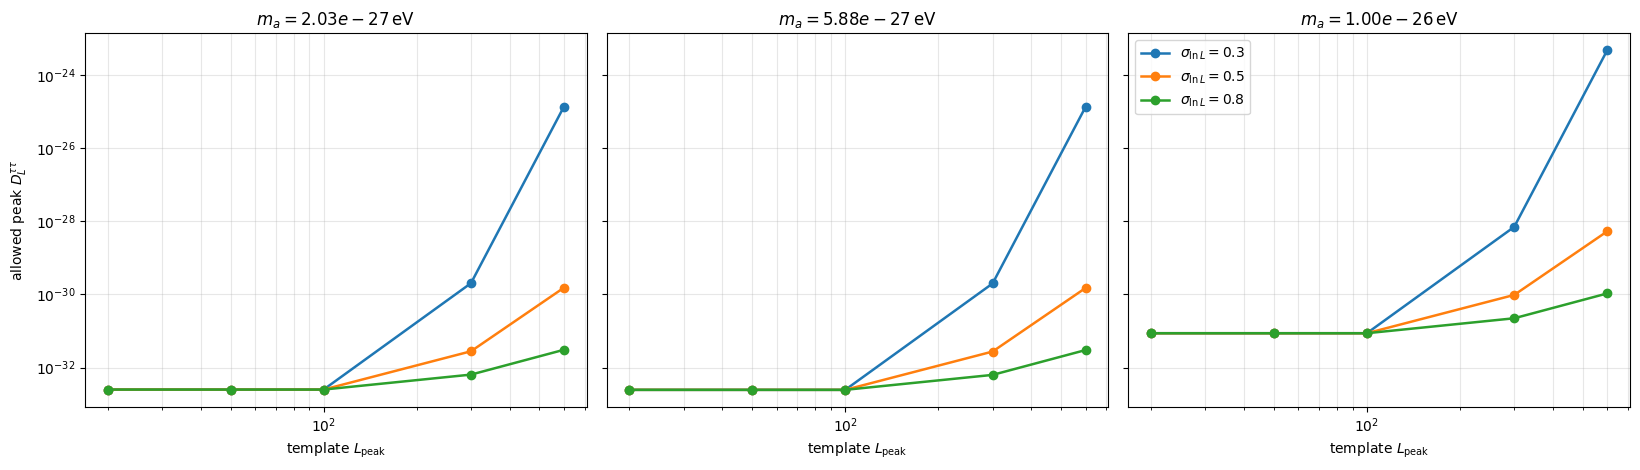

In [4]:
masses = sorted(summary['mass_eV'].unique())
fig, axes = plt.subplots(1, len(masses), figsize=(5.5 * len(masses), 4.8), sharey=True)
if len(masses) == 1:
    axes = [axes]
for ax, mass in zip(axes, masses):
    sub = summary[summary['mass_eV'] == mass]
    for sigma_log, grp in sub.groupby('sigma_log'):
        grp = grp.sort_values('L_peak_template')
        ax.loglog(grp['L_peak_template'], grp['D_peak_limit'], marker='o', lw=1.8, label=fr'$\sigma_{{\ln L}}={sigma_log:g}$')
    ax.set_title(fr'$m_a={mass:.2e}\,{{\rm eV}}$')
    ax.set_xlabel(r'template $L_{\rm peak}$')
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel(r'allowed peak $D_L^{\tau\tau}$')
axes[-1].legend()
plt.tight_layout()
plt.show()


## Strongest / weakest limits in the scanned family

In [5]:
rows = []
for mass in masses:
    sub = summary[summary['mass_eV'] == mass].copy()
    strongest = sub.loc[sub['D_peak_limit'].idxmin()]
    weakest = sub.loc[sub['D_peak_limit'].idxmax()]
    rows.append({
        'mass_eV': mass,
        'strongest_template': strongest['template_name'],
        'strongest_D_peak_limit': strongest['D_peak_limit'],
        'weakest_template': weakest['template_name'],
        'weakest_D_peak_limit': weakest['D_peak_limit'],
    })
pd.DataFrame(rows)


,mass_eV,strongest_template,strongest_D_peak_limit,weakest_template,weakest_D_peak_limit
0,2.030918e-27,Lpeak_20_siglog_0.3,2.492998e-33,Lpeak_600_siglog_0.3,1.388706e-25
1,5.878016e-27,Lpeak_20_siglog_0.3,2.450067e-33,Lpeak_600_siglog_0.3,1.364791e-25
2,1.000000e-26,Lpeak_20_siglog_0.3,8.698126e-32,Lpeak_600_siglog_0.3,4.845224e-24


## Reading note

この notebook の simplified reinterpretation では、template family 依存性は主に
「bump のどれだけが $L\lesssim 100$ の観測レンジに入るか」から来ます。
したがって、高い $L_{\rm peak}$ にある patchy template ほど制限は弱く見えます。